# Model 3 Neural Network



## 1 - Packages

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from utils import load_split


%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

All packages loaded successfully.


## 2 - Loading data

In [88]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [117]:
#Scale input data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Integers to one-hot vectors
y_train_multi = to_categorical(y_train, num_classes=40)
y_val_multi   = to_categorical(y_val, num_classes=40)
y_test_multi = to_categorical(y_test, num_classes=40)

# Map Class 16 to 0, all other to 1
y_train_bin = np.where(y_train == 16, 0, 1)
y_val_bin   = np.where(y_val == 16, 0, 1)
y_test_bin = np.where(y_test == 16, 0, 1)

# Multiclass to binary
y_binary = np.where(y_train == 16, 0, 1)
print("Class counts:")
print(pd.Series(y_binary).value_counts())
# You should now see only 0s and 1s

Class counts:
0    53874
1    46904
Name: count, dtype: int64


## 4 - Multi-classification

### 4.1 - Training model 3MCv1: Neural network with 20 training cycles and no regularisation 

In [134]:
input_shape = (X_train_scaled.shape[1],) 
num_classes = 40
print("--- Building Model 3MCv1 ---")
# Build Model 1 (Neural network with 20 training cycles, no early stopping)
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

# Train
print("Training  Model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train_scaled, y_train_multi,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi)
)

--- Building Model 3MCv1 ---
Training  Model 3MCv1...
Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9541 - loss: 0.2024 - val_accuracy: 0.9883 - val_loss: 0.0458
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9830 - loss: 0.0620 - val_accuracy: 0.9900 - val_loss: 0.0367
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9859 - loss: 0.0509 - val_accuracy: 0.9913 - val_loss: 0.0304
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9875 - loss: 0.0437 - val_accuracy: 0.9917 - val_loss: 0.0282
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9892 - loss: 0.0385 - val_accuracy: 0.9919 - val_loss: 0.0280
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9893 - loss: 0.0363 - val_accuracy: 0.9920 - val_loss: 0.0269
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9897 - loss: 0.0348 - val_accuracy: 0.9927 - val_loss: 0.0261
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━

### 4.2 - Prediction and accuracy Model 3MCv1

In [ ]:
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test_scaled)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report 3MCv1 ---")
report = classification_report(y_true_integers, y_pred_3MCv1, output_dict=True)
print(classification_report(y_true_integers, y_pred_3MCv1))

705/705 - 1s - 1ms/step - accuracy: 0.7130 - loss: 17.2314

Test Accuracy: 71.30%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       1.00      0.91      0.95       359
           2       0.75      0.15      0.25        20
           3       0.33      0.67      0.44         3
           4       1.00      0.00      0.01      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.72      0.98      0.83       141
           8       0.88      1.00      0.93         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94      1.00 

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 4.3 - Training model 3MCv2: Neural network with L1 regularisation with early stopping mechanism

In [136]:
print("--- Building Model 3MCv2 (L1 Regularized) ---")

model_3MCv2 = Sequential([
    Dense(128, activation='relu', 
                 input_shape=input_shape,
                 kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv2.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

print("Starting training...")
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_3MCv2 = model_3MCv2.fit(
    X_train_scaled, y_train_multi,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi),
    callbacks=[early_stopping],
    verbose=1
)


--- Building Model 3MCv2 (L1 Regularized) ---
Starting training...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9494 - loss: 0.3931 - val_accuracy: 0.9839 - val_loss: 0.1447
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9770 - loss: 0.1541 - val_accuracy: 0.9856 - val_loss: 0.1182
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9799 - loss: 0.1296 - val_accuracy: 0.9881 - val_loss: 0.1011
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9818 - loss: 0.1181 - val_accuracy: 0.9869 - val_loss: 0.0941
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9827 - loss: 0.1105 - val_accuracy: 0.9881 - val_loss: 0.0880
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9834 - loss: 0.1058 - val_accuracy: 0.9877 - val_loss: 0.0907
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9838 - loss: 0.1044 - val_accuracy: 0.9896 - val_loss: 0.0861
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9845 - loss: 0.0986 - val_accurac

### 4.4 - Prediction and accuracy Model 3MCv2

In [ ]:
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test_scaled)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report 3MCv2 ---")
report = classification_report(y_true_integers, y_pred_3MCv2, output_dict=True)
print(classification_report(y_true_integers, y_pred_3MCv2))

705/705 - 1s - 1ms/step - accuracy: 0.7123 - loss: 5.2836

Test Accuracy: 71.23%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.67      0.98      0.79       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       1.00      0.01      0.02      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.89      0.98      0.93       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94      1.00  

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 4.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

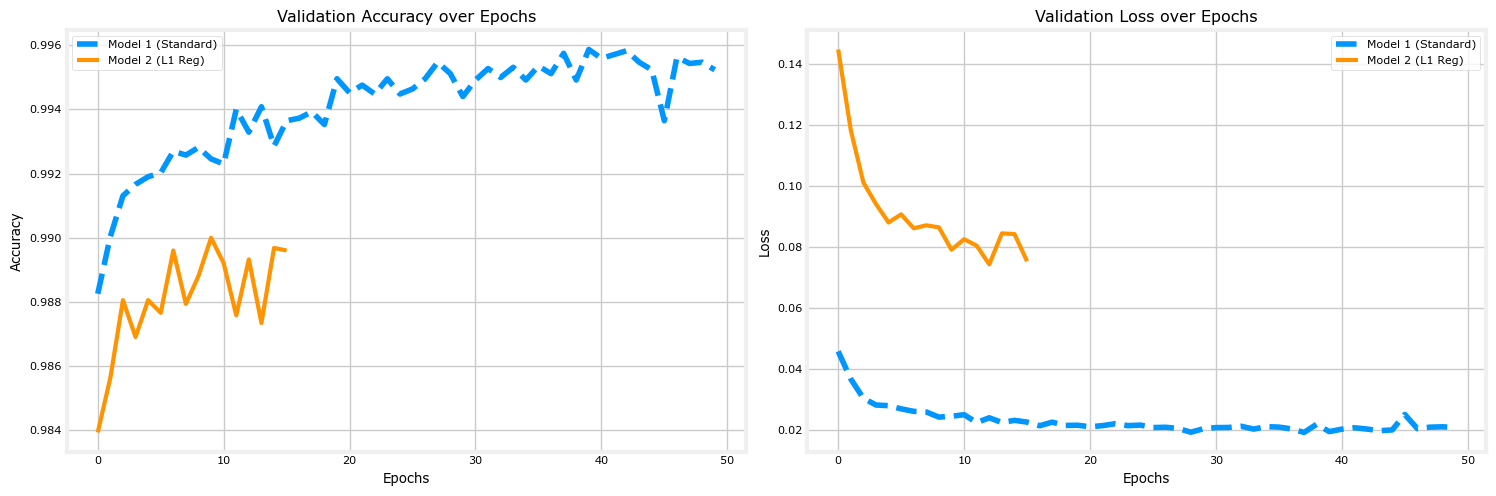

--- Final Project Results ---
          Metric Model 3MCv1 (Standard) Model 3MCv2 (L1 Regularized)
0  Test Accuracy                 71.30%                       71.23%
1  Features Used         All 41 (Dense)     All 41 (Sparse/Filtered)


In [140]:
plt.close('all') 
# Create a clean figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Validation Accuracy Comparison
ax1.plot(history_3MCv1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
ax1.plot(history_3MCv2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
ax1.set_title('Validation Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Comparison
ax2.plot(history_3MCv1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
ax2.plot(history_3MCv2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
ax2.set_title('Validation Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout() 
plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3MCv1 (Standard)": [f"{test_acc_3MCv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3MCv2 (L1 Regularized)": [f"{test_acc_3MCv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)

## 5 - Binary classification

### 5.1 - Training model 3BINv1: Neural network with 20 training cycles and no regularisation 

In [141]:
print("--- Building Model 3BINv1 ---")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Training  Model 3BINv1...")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train_scaled, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_bin),
    verbose=1
)

--- Building Model 3BINv1 ---
Training  Model 3BINv1...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9761 - loss: 0.0701 - val_accuracy: 0.9900 - val_loss: 0.0301
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9885 - loss: 0.0370 - val_accuracy: 0.9906 - val_loss: 0.0256
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9898 - loss: 0.0293 - val_accuracy: 0.9921 - val_loss: 0.0215
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9908 - loss: 0.0263 - val_accuracy: 0.9929 - val_loss: 0.0202
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9937 - val_loss: 0.0189
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9923 - loss: 0.0222 - val_accuracy: 0.9941 - val_loss: 0.0178
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9945 - val_loss: 0.0171
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0200 - val_accurac

### 5.2 Prediction and accuracy Model 3BINv1

In [143]:
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test_scaled, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test_scaled)

y_pred_3BINv1 = (y_pred_3BINv1_probs > 0.5).astype("int32")

print("--- Classification Report 3MCv1 ---")
print(classification_report(y_test_bin, y_pred_3BINv1, target_names=['Normal', 'Attack']))


705/705 - 1s - 1ms/step - accuracy: 0.7842 - loss: 2.5567
Test Accuracy: 78.42%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step
--- Classification Report 3MCv1 ---
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



### 5.3 Training model 3BINv2: Neural network with L1 regularisation with early stopping mechanism

In [142]:
model_bin_3BINv2 = Sequential([
    Dense(128, activation='relu', 
          input_shape=input_shape,
          kernel_regularizer=tf.keras.regularizers.l1(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv2.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

early_stopping_bin = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training 3BINv2...")
history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train_scaled, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)

Training 3BINv2...
Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9734 - loss: 0.1907 - val_accuracy: 0.9874 - val_loss: 0.0843
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9843 - loss: 0.0838 - val_accuracy: 0.9865 - val_loss: 0.0661
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0721 - val_accuracy: 0.9875 - val_loss: 0.0638
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0690 - val_accuracy: 0.9904 - val_loss: 0.0573
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0670 - val_accuracy: 0.9884 - val_loss: 0.0600
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9865 - loss: 0.0644 - val_accuracy: 0.9867 - val_loss: 0.0588
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9866 - loss: 0.0639 - val_accuracy: 0.9897 - val_loss: 0.0532
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.986

### 5.4 Prediction and accuracy Model 3BINv2

In [144]:
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test_scaled, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test_scaled)

y_pred_3BINv2 = (y_pred_3BINv2_probs > 0.5).astype("int32")

print("--- Classification Report 3BINv2 ---")
print(classification_report(y_test_bin, y_pred_3BINv2, target_names=['Normal', 'Attack']))

705/705 - 1s - 1ms/step - accuracy: 0.7728 - loss: 0.9830
Test Accuracy: 77.28%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step
--- Classification Report 3BINv2 ---
              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



### 5.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

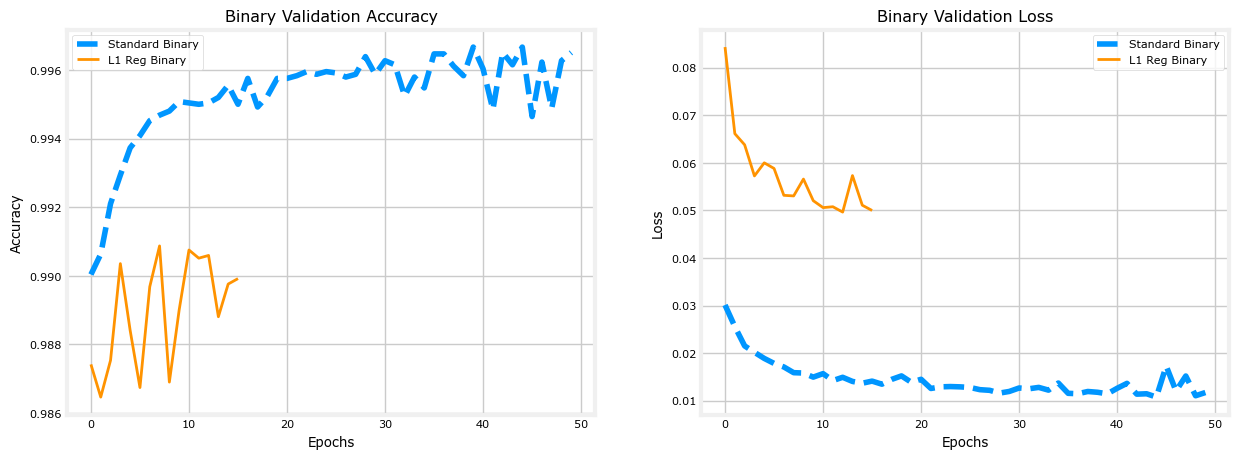

--- Final Project Results ---
          Metric Model 3BINv1 (Standard) Model 3BINv2 (L1 Regularized)
0  Test Accuracy                  78.42%                        77.28%
1  Features Used          All 41 (Dense)      All 41 (Sparse/Filtered)


In [145]:
plt.close('all') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(history_bin_3BINv1.history['val_accuracy'], label='Standard Binary', linestyle='--')
ax1.plot(history_bin_3BINv2.history['val_accuracy'], label='L1 Reg Binary', linewidth=2)
ax1.set_title('Binary Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history_bin_3BINv1.history['val_loss'], label='Standard Binary', linestyle='--')
ax2.plot(history_bin_3BINv2.history['val_loss'], label='L1 Reg Binary', linewidth=2)
ax2.set_title('Binary Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3BINv1 (Standard)": [f"{test_acc_3BINv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3BINv2 (L1 Regularized)": [f"{test_acc_3BINv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)
